## Parte 1

In [ ]:
!pip install numpy
!pip install matplotlib
!pip install pillow

In [ ]:
# Bibliotecas
import math
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

### Sinal corrompido pelo ruído deve ser representado por x[n] = s[n] + r[n]

In [ ]:
N = 1

resultado = np.zeros(200)
s = np.zeros(200)
r = np.zeros(200)

for n in range (0,200):
  s[n] = math.cos(0.8 * n) + 0.3 * math.sin(0.20 * n)
  r[n] = np.random.uniform(-0.3, 0.3, N)

  resultado[n] = s[n]+r[n]

print (resultado)
# resultado é o sinal corrompido que é o sinal de entrada

[ 0.99676536  0.84508374  0.11569762 -0.55983762 -0.85131668 -0.58918587
  0.33398913  0.98640605  1.06967673  0.9701272   0.20387088 -0.63768064
 -0.64385215 -0.6428258   0.20467638  0.72630514  0.81172614  0.68523932
 -0.35932035 -1.20915789 -0.96058202 -0.70618496  0.05063687  0.73555407
  0.75316455  0.34066212 -0.77689807 -1.17234814 -1.07201846 -0.38983458
  0.47400639  0.76862651  1.18230928  0.49751893 -0.45745215 -0.88665784
 -0.40759033  0.06159214  0.76640651  1.02047016  0.83504747  0.20826753
 -0.56067542 -0.64918739 -0.56770394  0.24827697  0.50477219  1.16731248
  0.63482361  0.17115492 -0.7934071  -1.2272676  -0.71147404 -0.3746963
  0.4565304   0.76654508  0.31361502 -0.2183806  -0.96784857 -1.003587
 -0.93785638  0.14871397  0.50598991  1.26108054  0.85365789 -0.15780604
 -0.69579475 -0.83709802 -0.10084124  0.28902816  1.19090987  1.04794415
  0.50685065  0.13223494 -0.66481766 -0.7378979  -0.1058575   0.34121356
  0.9213364   0.7316805   0.57647298 -0.46119861 -1.03

/tmp/ipykernel_2216/2667788697.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r[n] = np.random.uniform(-0.3, 0.3, N)


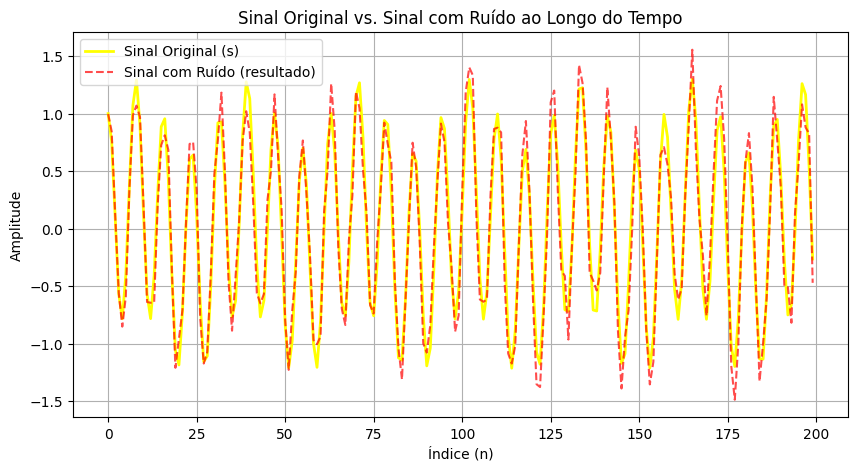

In [ ]:
n_values = np.arange(200)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(n_values, s, label='Sinal Original (s)', color='yellow', lw=2)

ax.plot(n_values, resultado, label='Sinal com Ruído (resultado)', color='red', linestyle='--', alpha=0.7)

ax.set_title('Sinal Original vs. Sinal com Ruído ao Longo do Tempo')
ax.set_xlabel('Índice (n)')
ax.set_ylabel('Amplitude')

ax.legend()

ax.grid(True)

plt.show()

### A resposta ao impulso h[n]
#### h[n] = (1 −a)(a)n · u[n].

In [ ]:
n = 0

h1 = np.zeros(200)
h2 = np.zeros(200)
h3 = np.zeros(200)

a1 = 0.5
a2 = 0.75
a3 = 0.95

for n in range(0,200):
  h1[n] = (1-a1) * (a1**n)* 1 # como os valores vão de 0 a 200, u[n] >= 0 então vai ser sempre 1

for n in range(0,200):
  h2[n] = (1-a2) * (a2**n)* 1

for n in range(0,200):
  h3[n] = (1-a3) * (a3**n)* 1

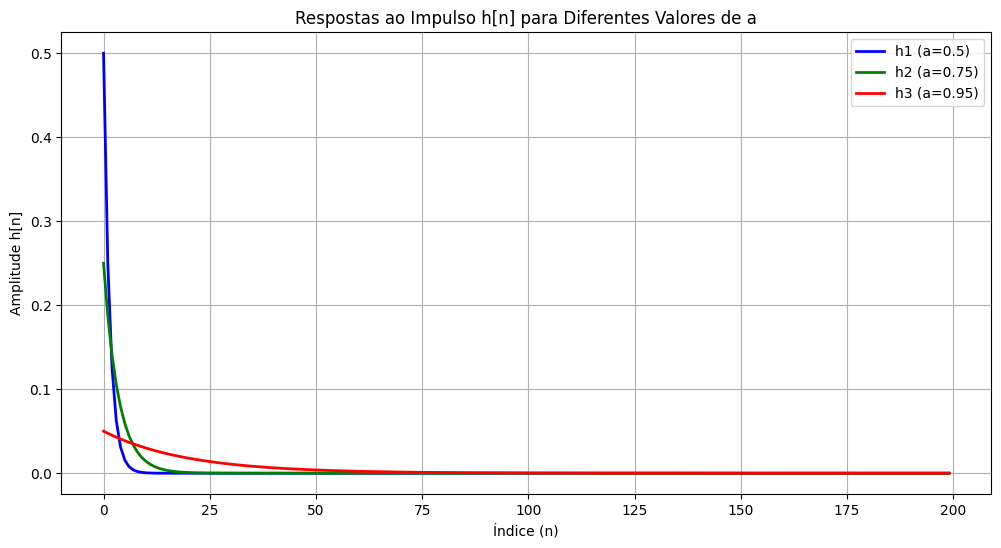

In [ ]:
n_values = np.arange(200)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(n_values, h1, label=f'h1 (a={a1})', color='blue', lw=2)

ax.plot(n_values, h2, label=f'h2 (a={a2})', color='green', lw=2)

ax.plot(n_values, h3, label=f'h3 (a={a3})', color='red', lw=2)

ax.set_title('Respostas ao Impulso h[n] para Diferentes Valores de a')
ax.set_xlabel('Índice (n)')
ax.set_ylabel('Amplitude h[n]')

ax.legend()

ax.grid(True)

plt.show()

### Convolução em tempo discreto
#### c[n] = x[n] ∗ h[n]

In [ ]:
def convol(x, h):
  len_x = len(x)
  len_h = len(h)

  len_c = len_x + len_h - 1

  c = np.zeros(len_c)

  for n in range(len_c):
    for k in range(len_x):
      if 0 <= n - k < len_h:
        c[n] += x[k] * h[n - k]

  return c

In [ ]:
c1 = convol(resultado, h1)

c2 = convol(resultado, h2)

c3 = convol(resultado, h3)


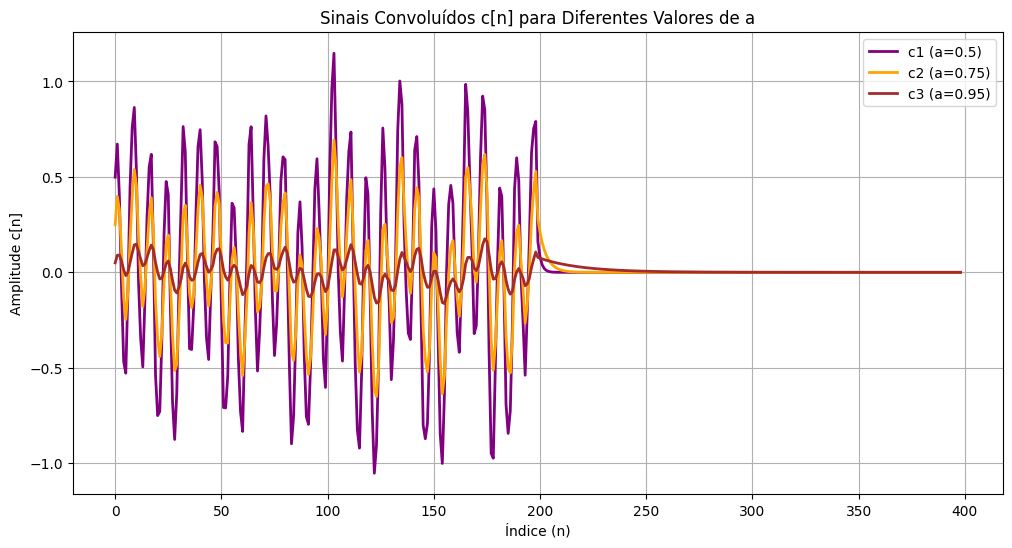

In [ ]:
n_values = np.arange(len(c1))

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(n_values, c1, label=f'c1 (a={a1})', color='purple', lw=2)

ax.plot(n_values, c2, label=f'c2 (a={a2})', color='orange', lw=2)

ax.plot(n_values, c3, label=f'c3 (a={a3})', color='brown', lw=2)

ax.set_title('Sinais Convoluídos c[n] para Diferentes Valores de a')
ax.set_xlabel('Índice (n)')
ax.set_ylabel('Amplitude c[n]')

ax.legend()

ax.grid(True)

plt.show()

## Parte 2

O aluno deve gerar um relatório
discutindo a implementação do código, e apresentado as imagens originais e filtradas.

c[x, y] = I[x, y] ∗ K[x, y]

I[x, y] -> Imagem

---

K[x, y] -> Resposta ao impulso

---

x e y representam as coordenadas de cada pixel da imagem

---

c[x, y] representa o resultado da operação de
convolução 2D

In [ ]:
def convol2d(image, kernel):

  image_height, image_width = image.shape
  kernel_height, kernel_width = kernel.shape

  output_height = image_height - kernel_height + 1
  output_width = image_width - kernel_width + 1

  output = np.zeros((output_height, output_width))
  # image
  for i in range(output_height):
    for j in range(output_width):
      sum_val = 0
      # kernel
      for kh in range(kernel_height):
        for kw in range(kernel_width):

          sum_val += image[i + kh, j + kw] * kernel[kh, kw]

      output[i, j] = sum_val

  return output

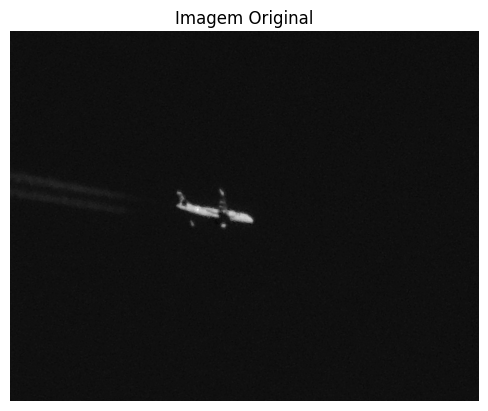

In [ ]:
img = Image.open('/content/DSCN2956.JPG')
imagem = np.array(img.convert('L'))

plt.imshow(imagem, cmap='gray')
plt.title('Imagem Original')
plt.axis('off')
plt.show()

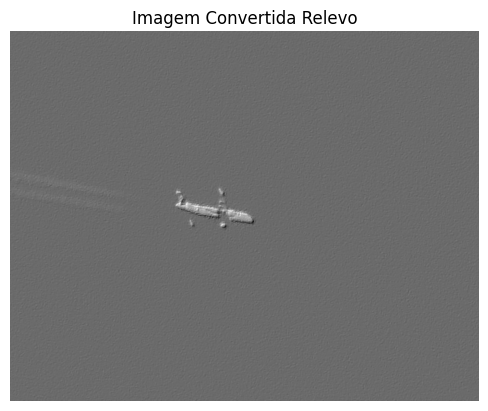

In [ ]:
# criação dos filtros de acordo com o enunciado
k_relevo = np.array([ [-2, -1, 0],
                      [-1, 1, 1],
                      [ 0, 1, 2] ])

k_bordas = np.array([ [-1, -2, -1],
                      [0, 0, 0],
                      [1, 2, 1] ])

imagem_convertida_relevo_pequena = convol2d (imagem, k_relevo)

plt.imshow(imagem_convertida_relevo_pequena, cmap='gray')
plt.title('Imagem Convertida Relevo')
plt.axis('off')
plt.show()

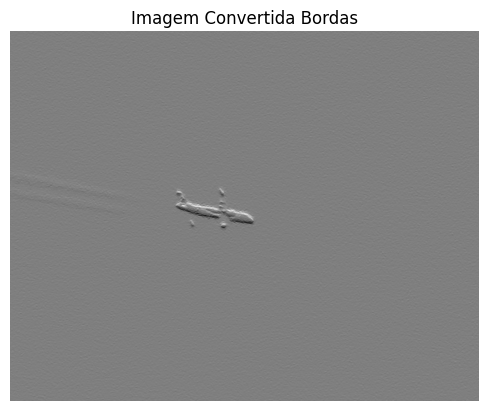

In [ ]:
imagem_convertida_bordas = convol2d (imagem, k_bordas)

plt.imshow(imagem_convertida_bordas, cmap='gray')
plt.title('Imagem Convertida Bordas')
plt.axis('off')
plt.show()

Utilizei como base para aprender o código da convolução 2D esse artigo no Medium: https://medium.com/@er_95882/convolution-image-filters-cnns-and-examples-in-python-pytorch-bd3f3ac5df9c